In [1]:
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


In [2]:
import p3o
from systems import *
from simulator import *
from utils import *

# Simulator

In [3]:
run_name = "cascade_observability_reward"

env = Simulator(
    Cascade(
        x_dim=2,
        u_dim=2,
        y_dim=1,
        w_std=0.01,
        action_range=(-0.05, 5.0),
        actuator_faults=True,
        sensor_faults=False,
    ),
    t_aux_on=32,
    t_aux_off=96,
    episode_length=128,
    ref=References(y=1.0, u=0.0, a=0.0, x=0.0, z=0.0),
    Jcontrol=ControlCostMatrices(y=1.0, u=1.0, a=1.0, x=0.0, z=0.0),
    Jaux=None,  # AuxCostMatrices(z=1.0, x=0.1),
    obs_gramian_eps=0.05,  # None,
    kalman_params=dict(Qz=1e-8, Qx=1e-2, R=1e-2),
    mpc_params=dict(
        horizon=16,
        discount=0.9,
        integral_action=True,
        newton_iters=1,
        mc_samples_traj=0,
    ),
)
nnx.display(env)

# Setup Trainer

In [4]:
trainer = p3o.Trainer(
    env=env,
    max_cost=1.0,
    pool_size=128,
    discount=0.99,
    gae_lambda=0.95,
    clip_pi=0.1,
    clip_vf=1.0,
    min_cost_weight=0.0,
    max_cost_weight=20.0,
    min_entropy_weight=1e-10,
    max_entropy_weight=1e-3,
    normalize_advantages=True,
    stationary=False,
    policy_hidden_dim=16,
    value_hidden_dim=32,
    rngs=env.rngs,
)
trainer.train(epochs=0)
nnx.display(trainer)

0it [00:00, ?it/s]


# Train

In [5]:
trainer.train(epochs=500, policy_lr=1e-4, value_lr=1e-3)
trainer.dump(run_name)
logger = trainer.logger

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [02:19<00:00,  3.58it/s, V=4.435555642930262, Vc=0.9608496234531818] 


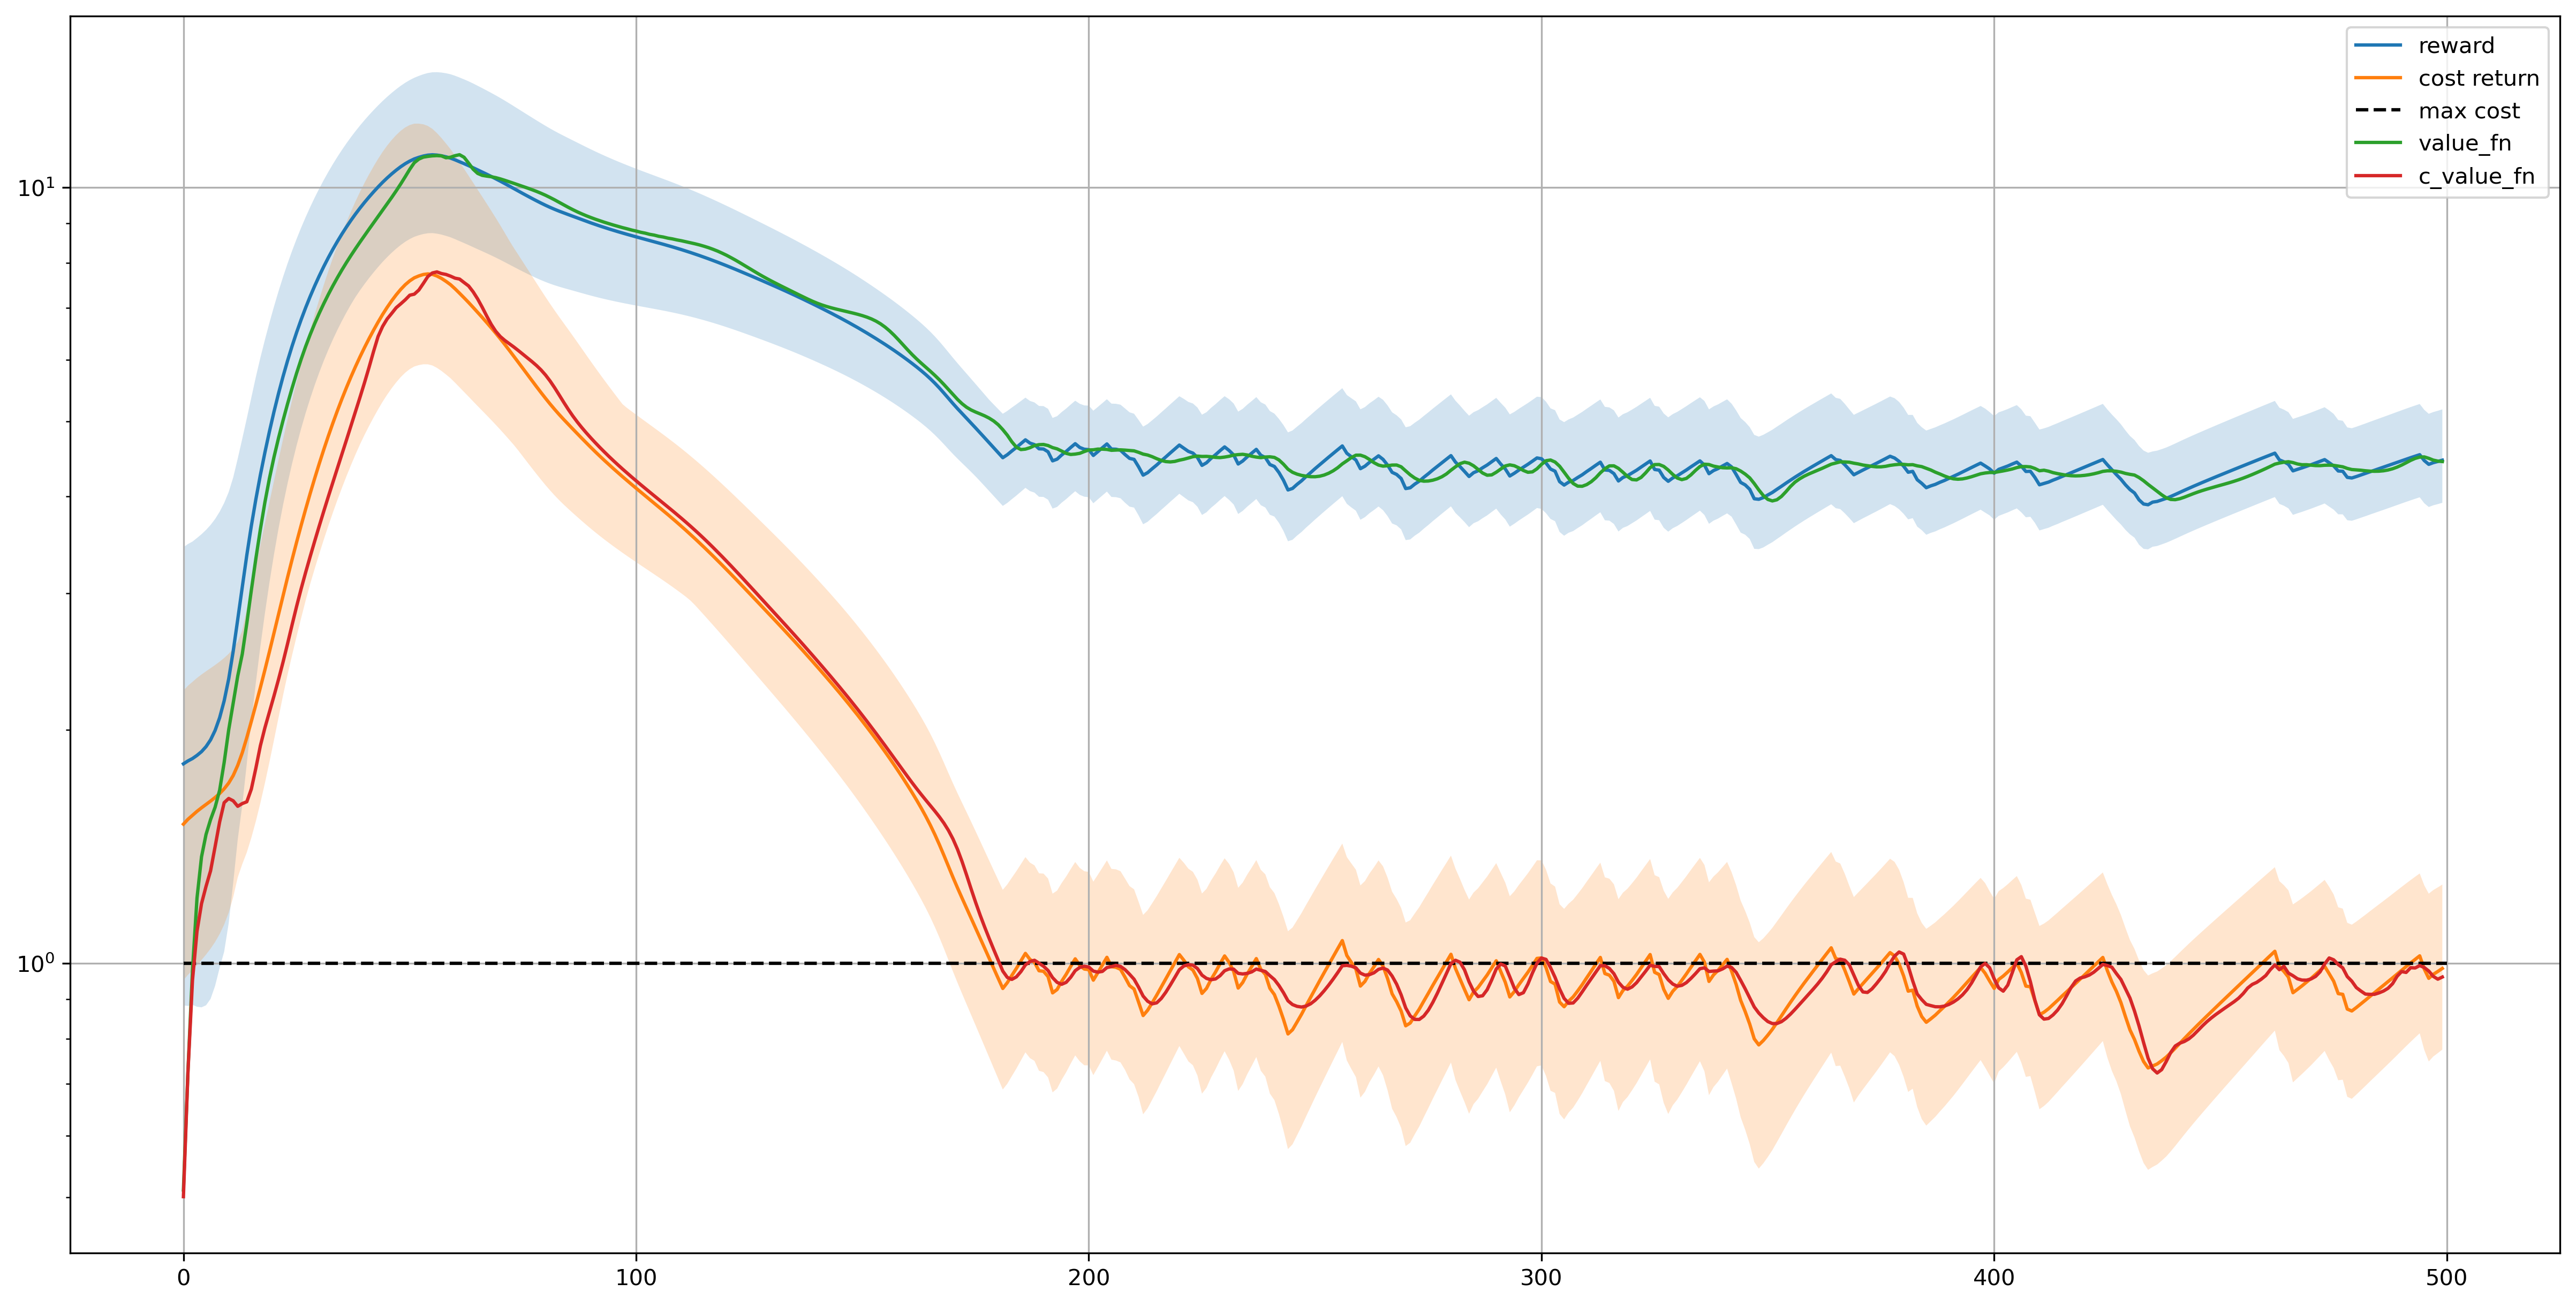

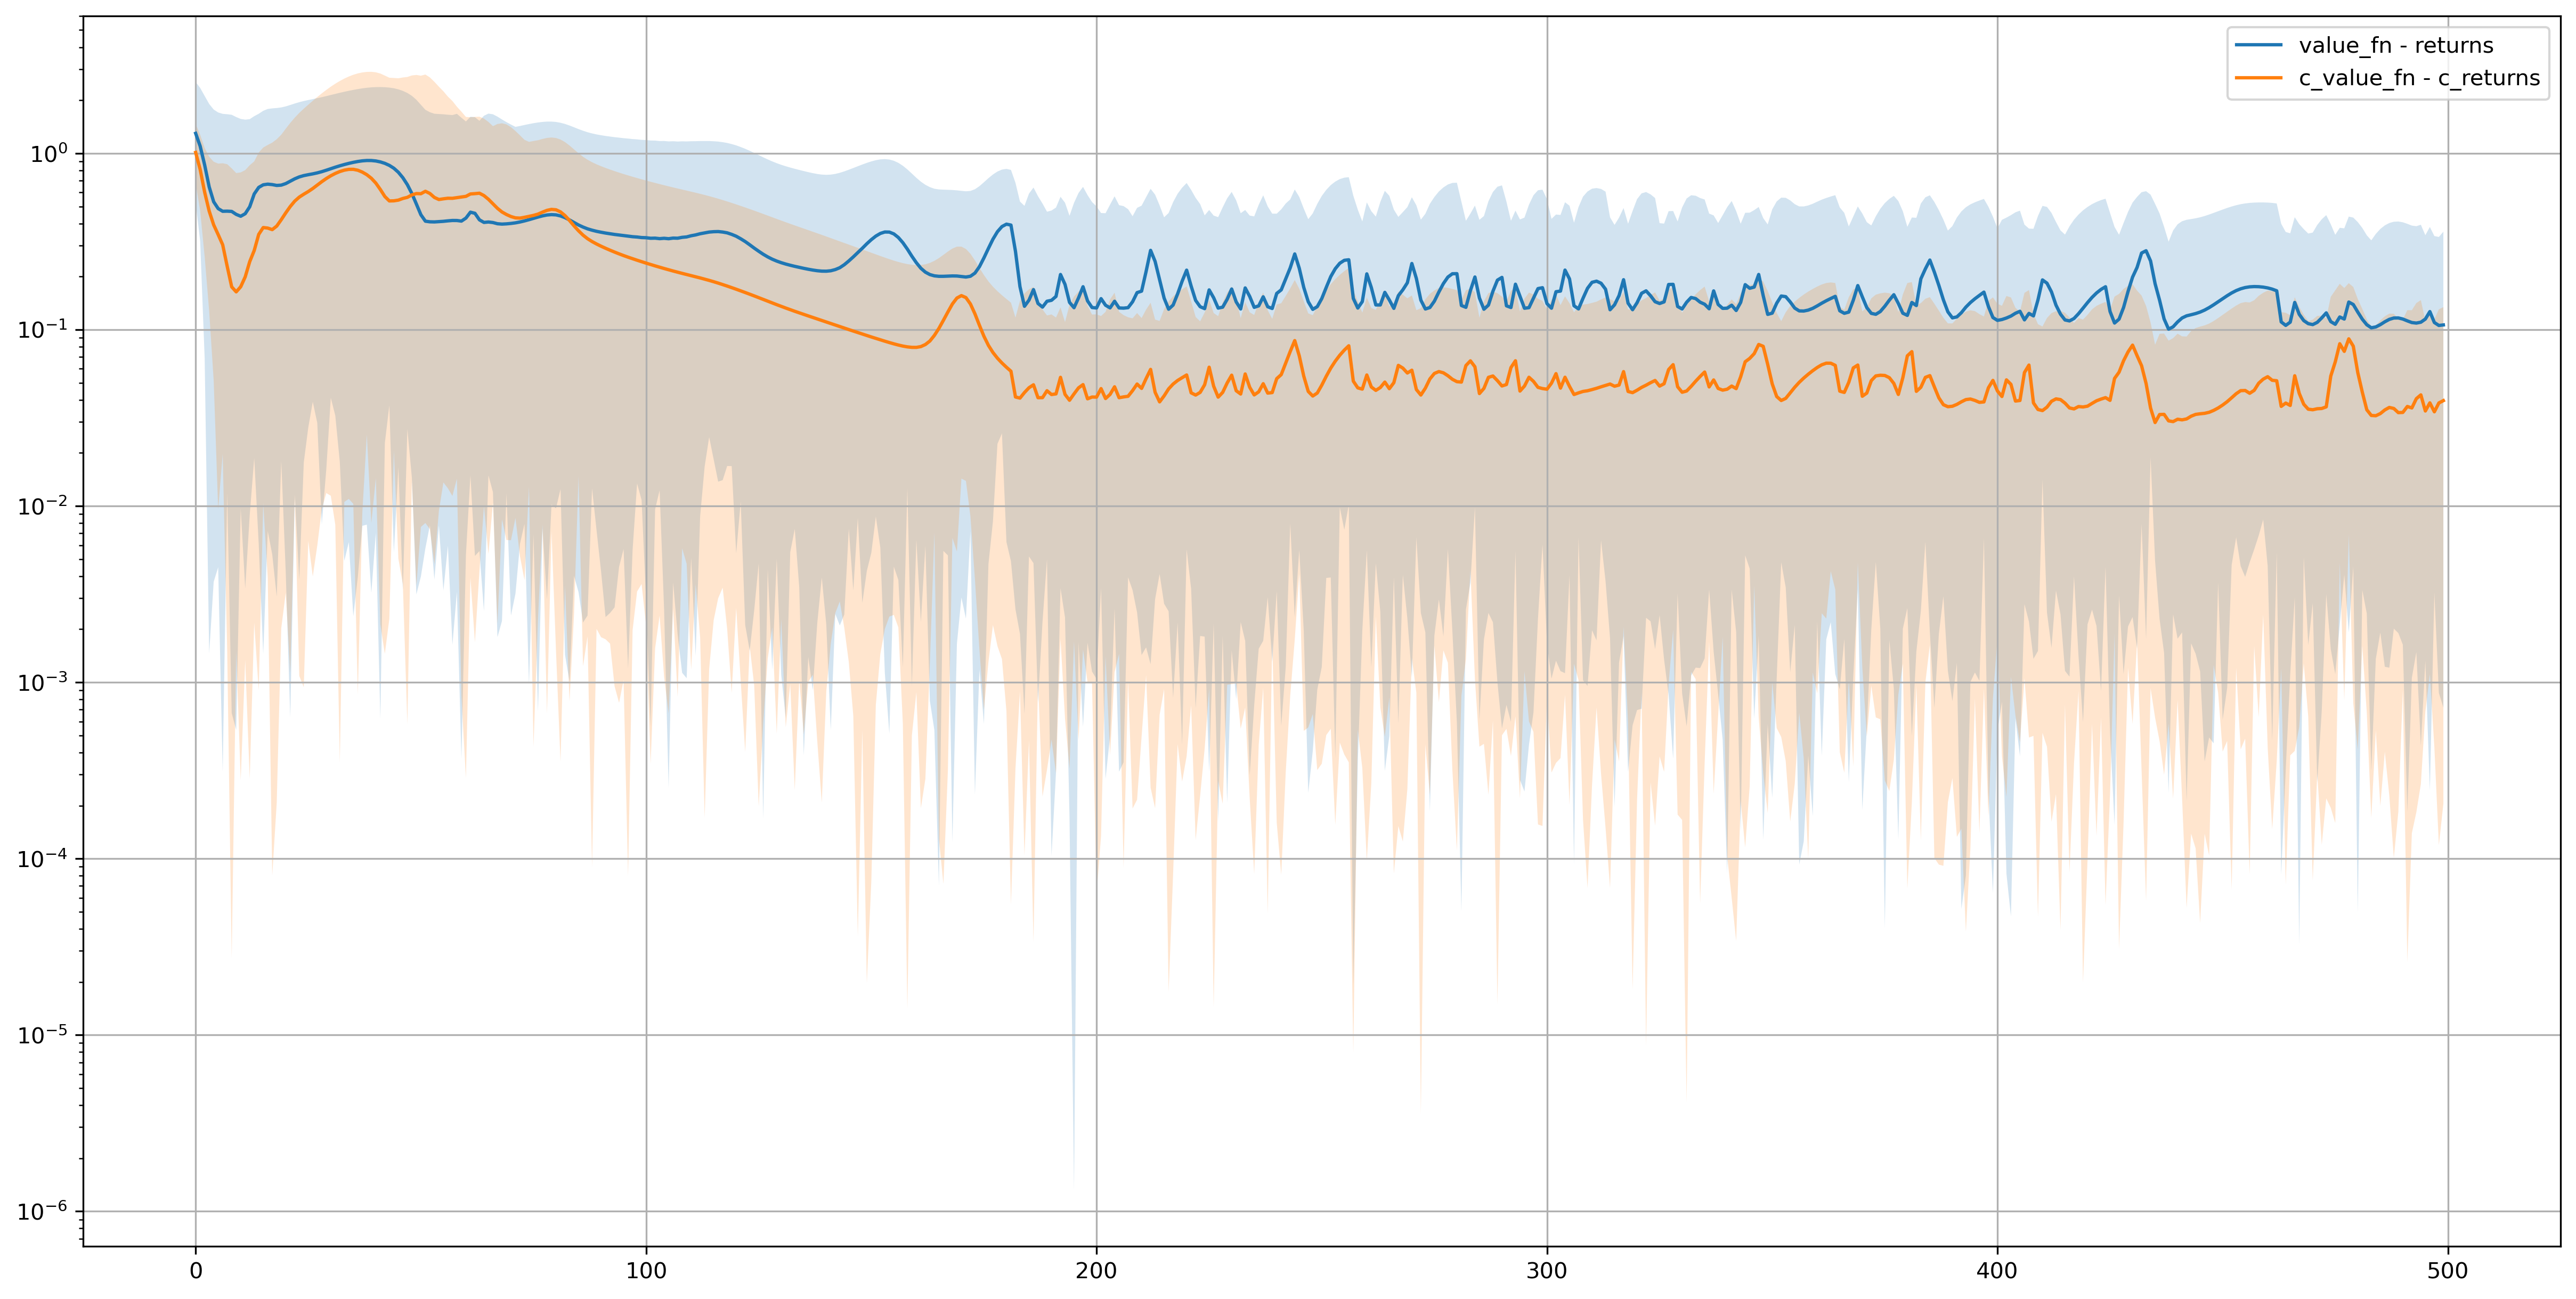

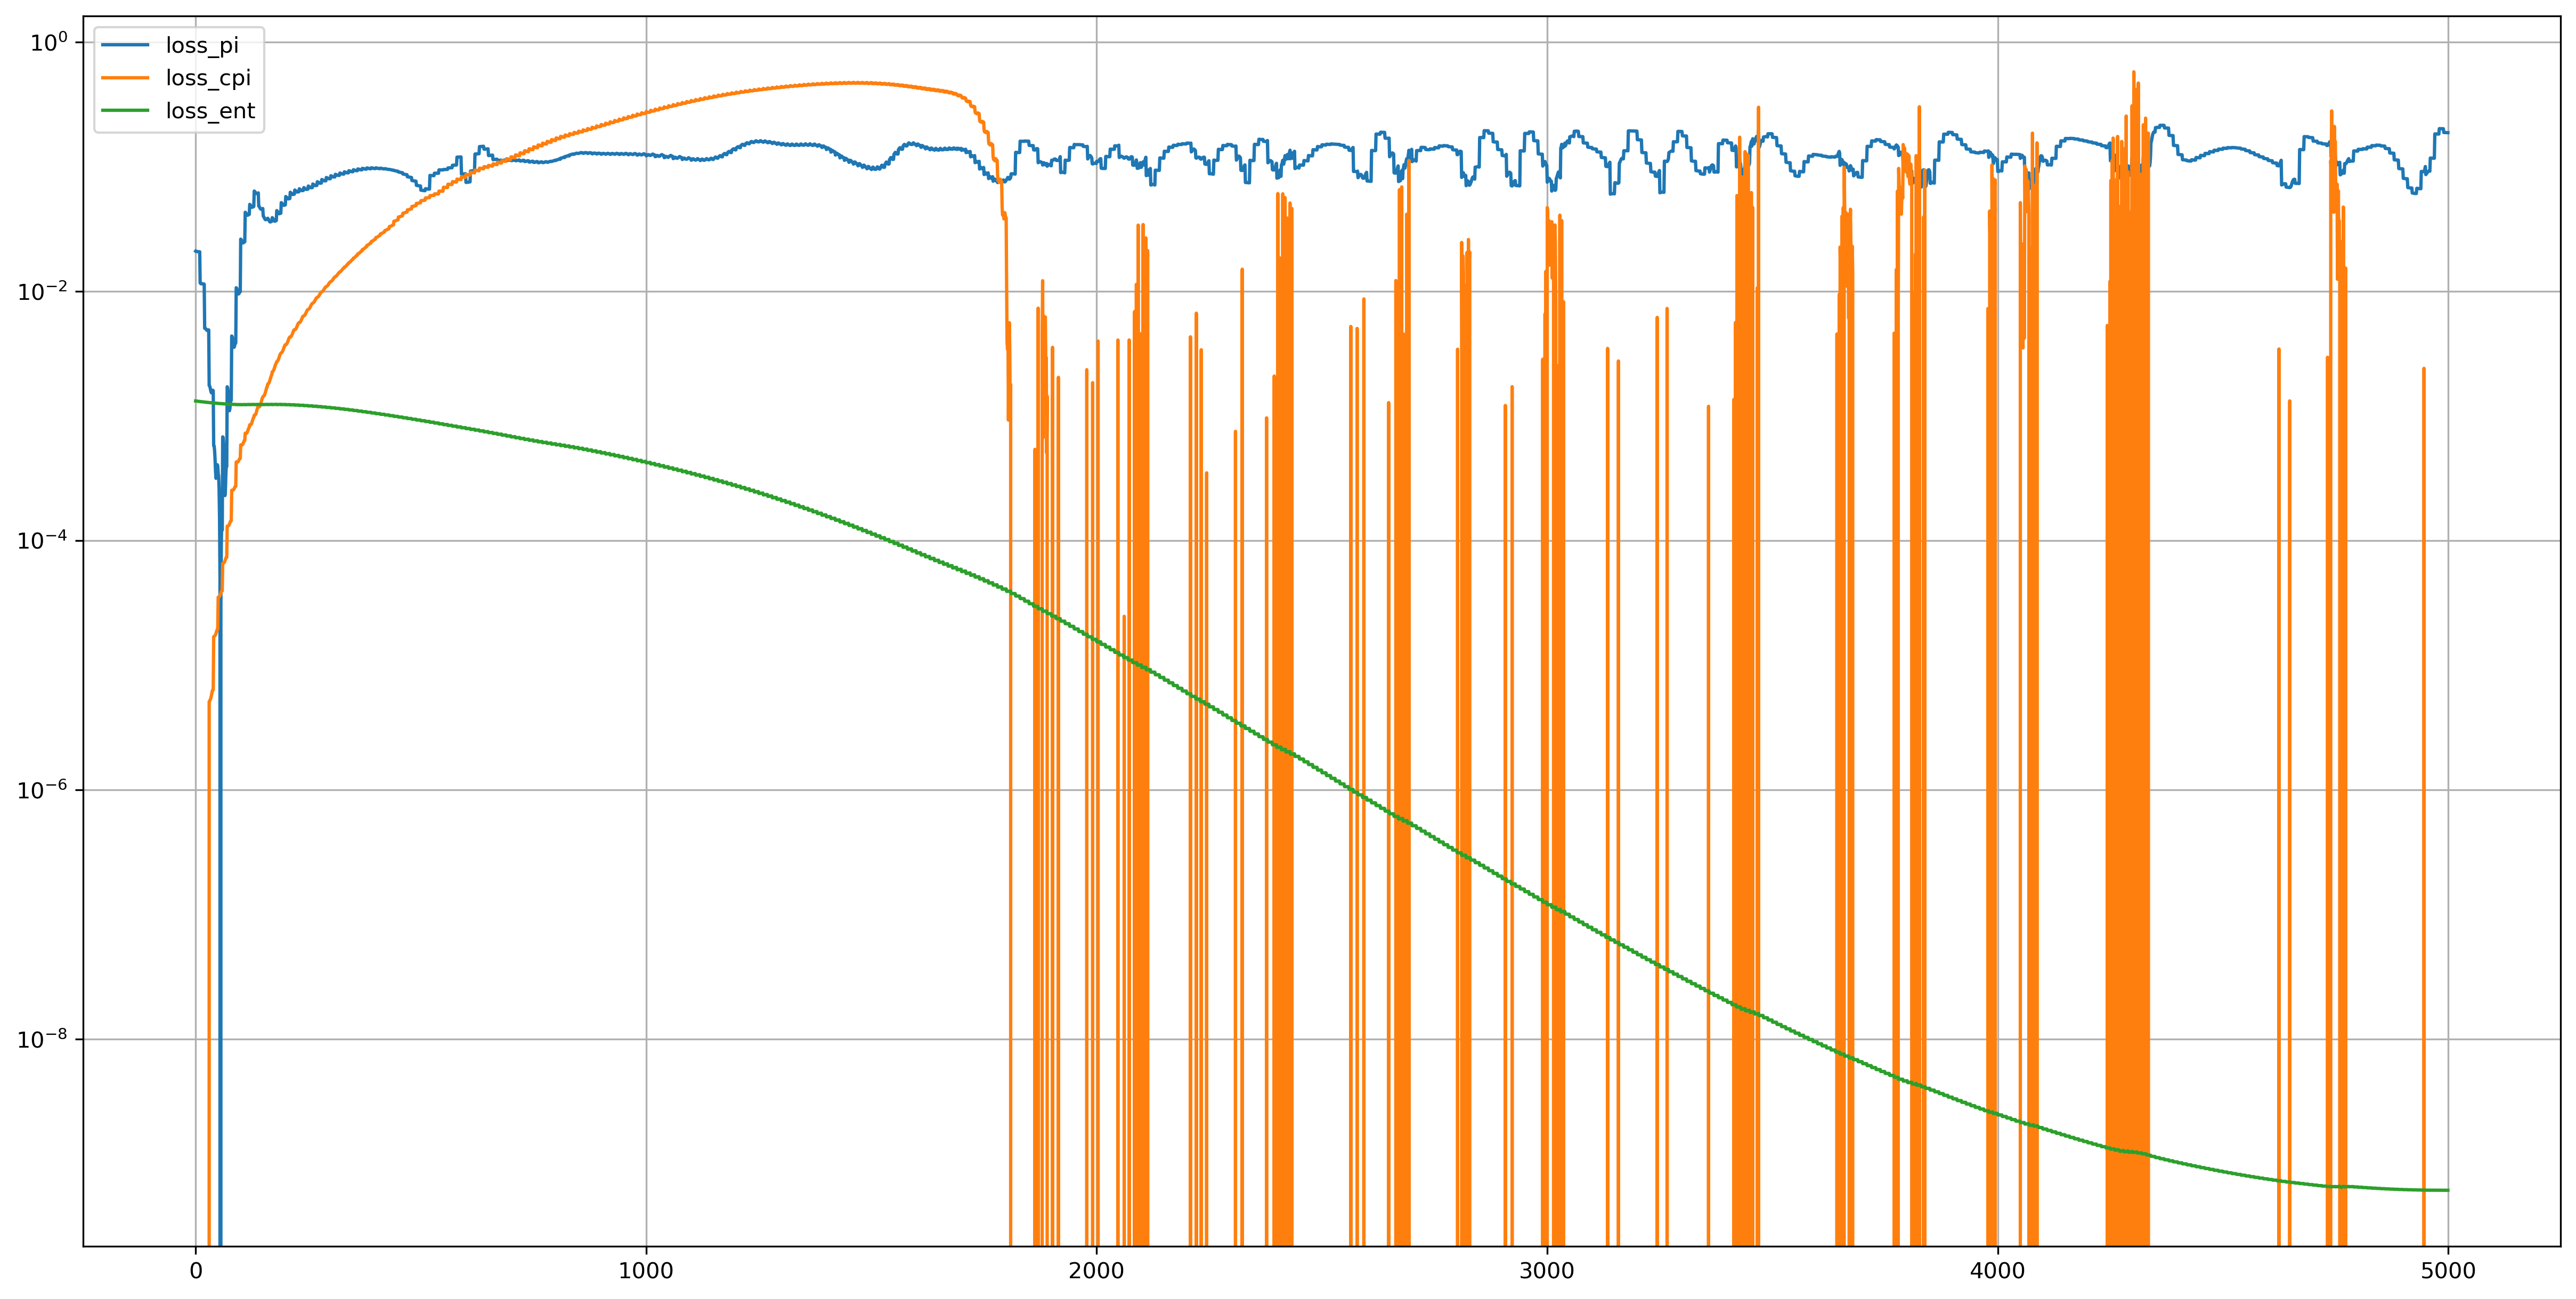

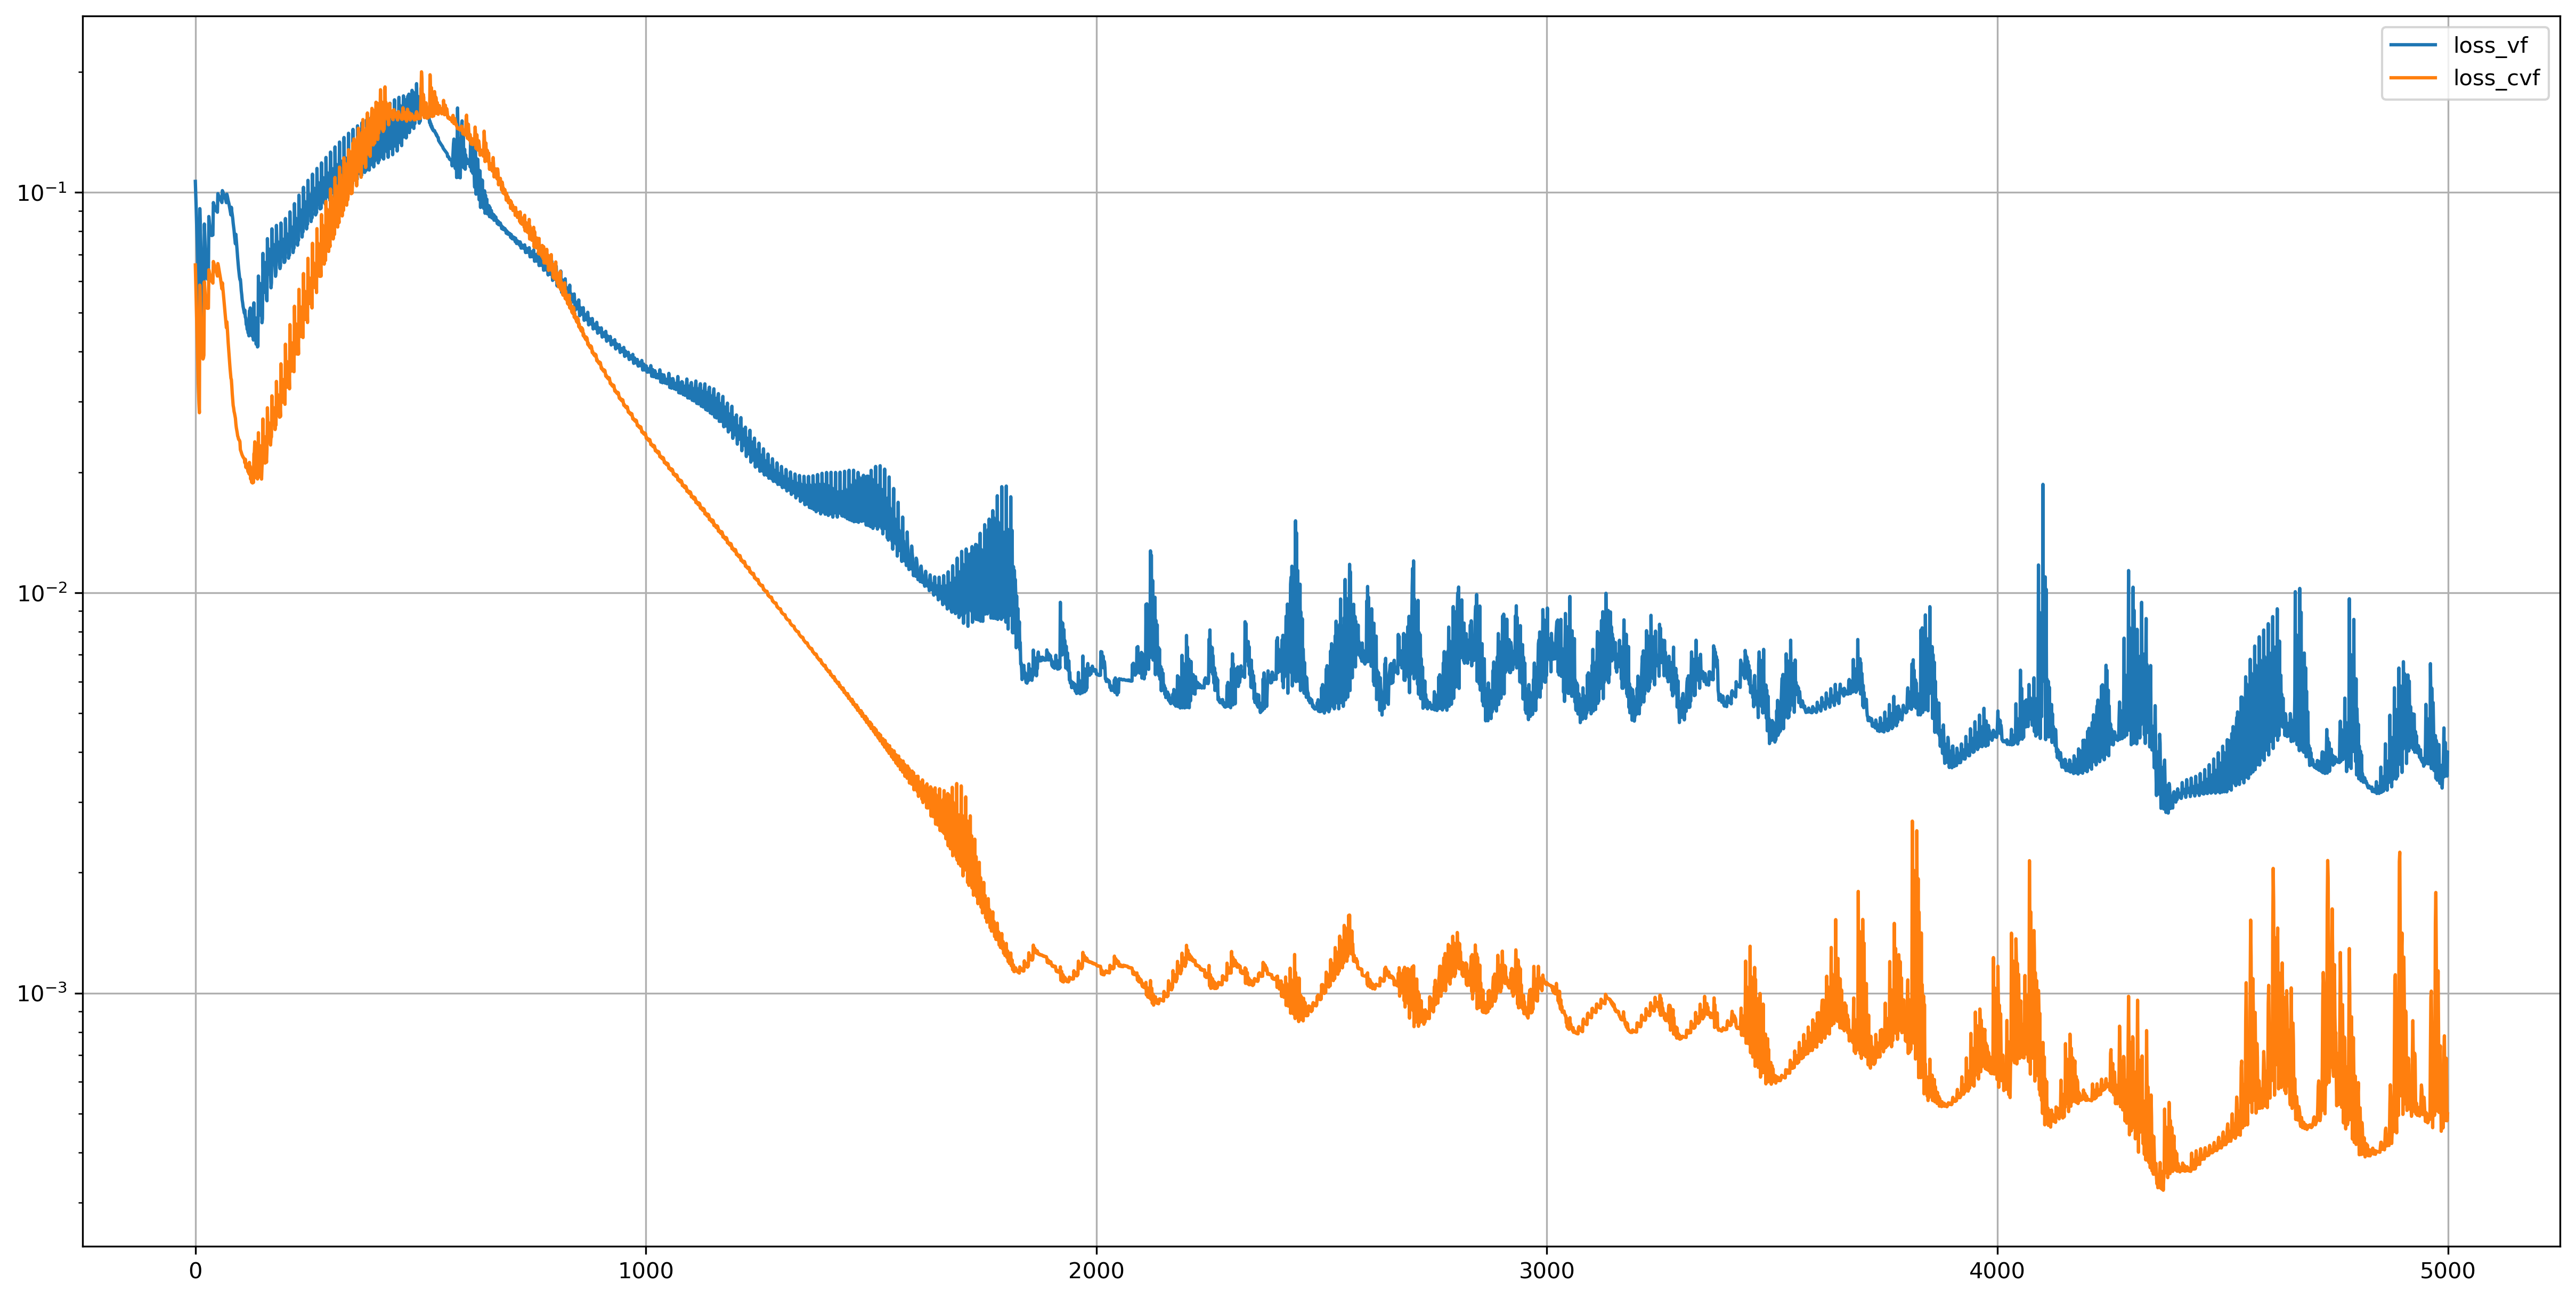

In [6]:
import matplotlib.pyplot as plt

batch_returns = jax.vmap(jax.vmap(lambda x: get_returns(x, trainer.discount)[0]))
r = batch_returns(logger["reward"])
V = logger["V"][:, :, 0]
r, V = jnp.abs(r), jnp.abs(V)
c = batch_returns(logger["cost"])
C = logger["Vc"][:, :, 0]

fig = plt.figure(figsize=(20, 10), dpi=300)
plt.semilogy(r.mean(-1), label="reward")
plt.fill_between(range(len(r)), r.min(-1), r.max(-1), alpha=0.2)
plt.semilogy(c.mean(-1), label="cost return")
plt.fill_between(range(len(r)), c.min(-1), c.max(-1), alpha=0.2)
plt.hlines(trainer.max_cost, 0, len(c), ["k"], "dashed", label="max cost")
plt.semilogy(V.mean(-1), label="value_fn")
plt.semilogy(C.mean(-1), label="c_value_fn")
plt.legend()
plt.grid()

fig = plt.figure(figsize=(20, 10), dpi=300)
plt.semilogy(jnp.abs(V - r).mean(-1), label="value_fn - returns")
plt.fill_between(range(len(r)), jnp.abs(V - r).min(-1), jnp.abs(V - r).max(-1), alpha=0.2)
plt.semilogy(jnp.abs(C - c).mean(-1), label="c_value_fn - c_returns")
plt.fill_between(range(len(r)), jnp.abs(C - c).min(-1), jnp.abs(C - c).max(-1), alpha=0.2)
plt.hlines(0.0, 0, len(c), ["k"], "dashed")
plt.legend()
plt.grid()
fig.show()

fig = plt.figure(figsize=(20, 10), dpi=300)
plt.semilogy(logger["loss_pi"] - logger["loss_pi"].min(), label="loss_pi")
plt.semilogy(logger["loss_cpi"], label="loss_cpi")
plt.semilogy(logger["loss_ent"], label="loss_ent")
plt.legend()
plt.grid()

fig = plt.figure(figsize=(20, 10), dpi=300)
plt.semilogy(logger["loss_vf"], label="loss_vf")
plt.semilogy(logger["loss_cvf"], label="loss_cvf")
plt.legend()
plt.grid()

# Rollouts

Mean return: 4.513788254125518 +- 0.35812405531901154
Mean cost: 0.9699236585639751 +- 0.0995791914925797


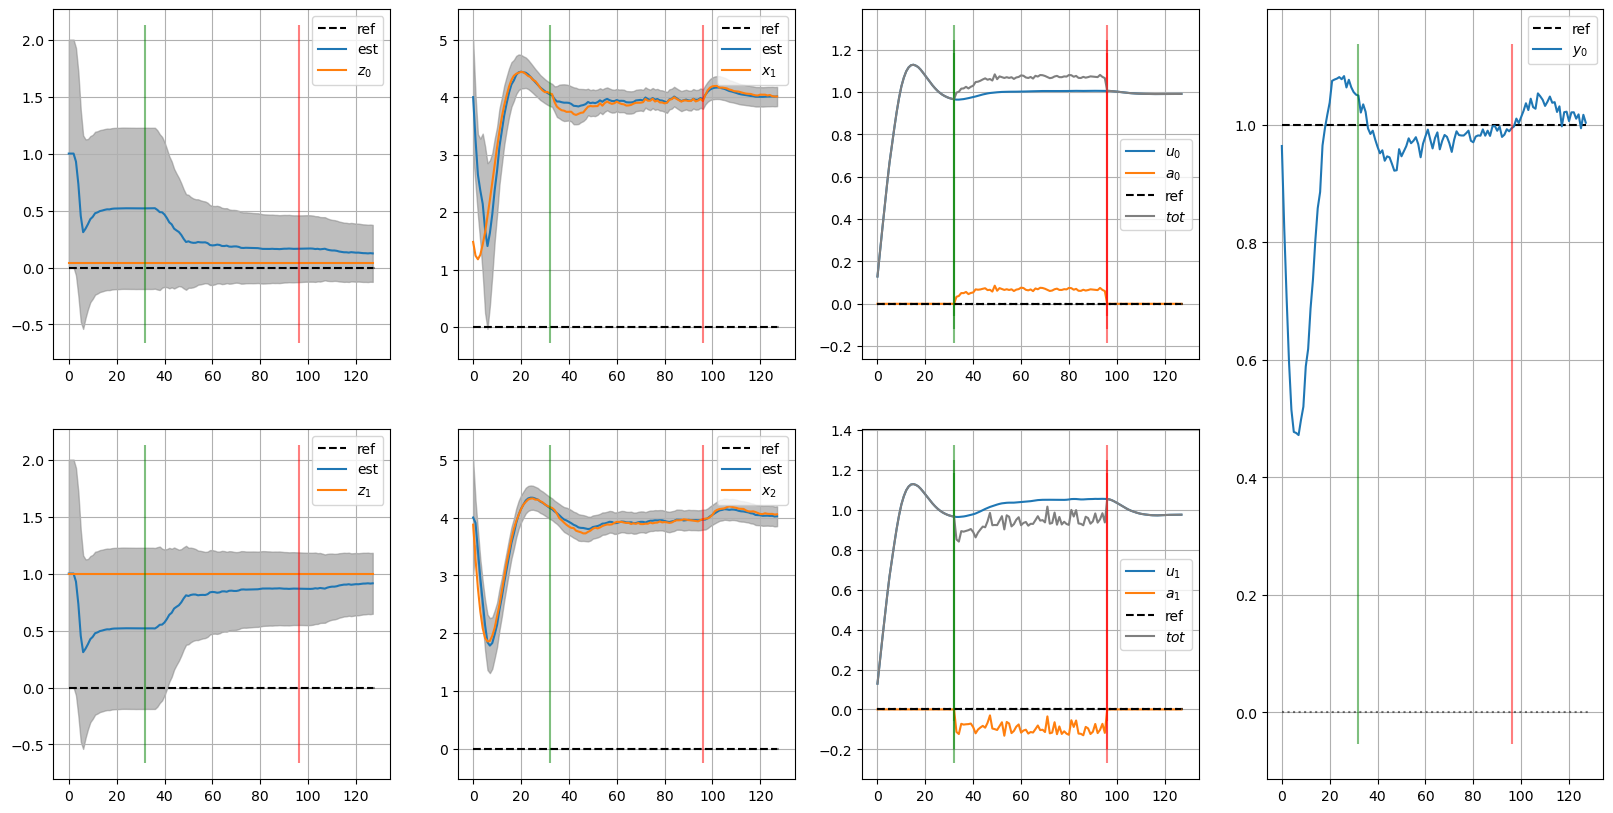

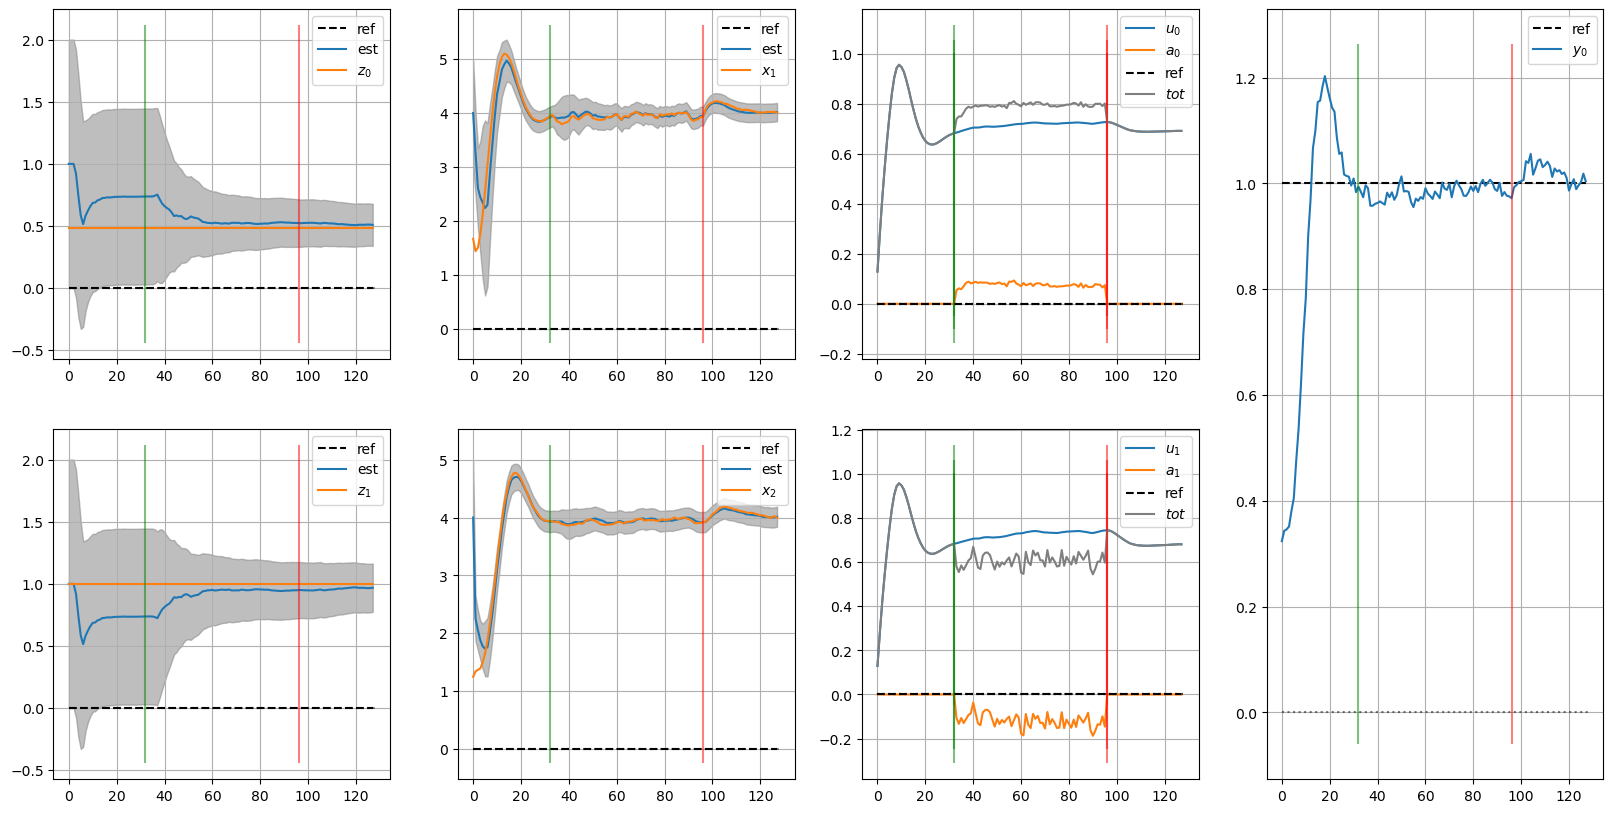

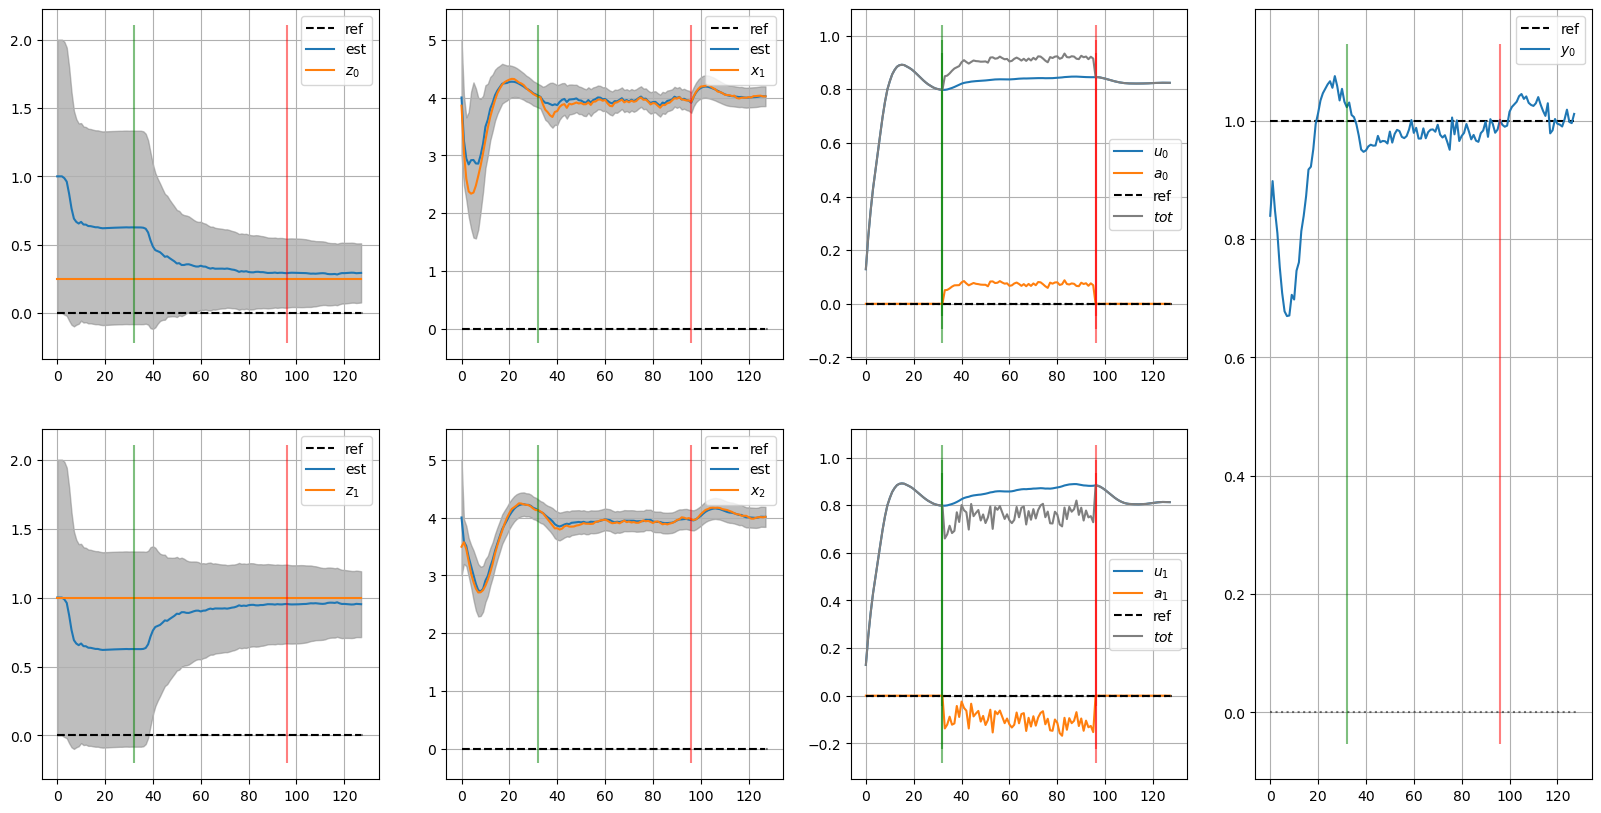

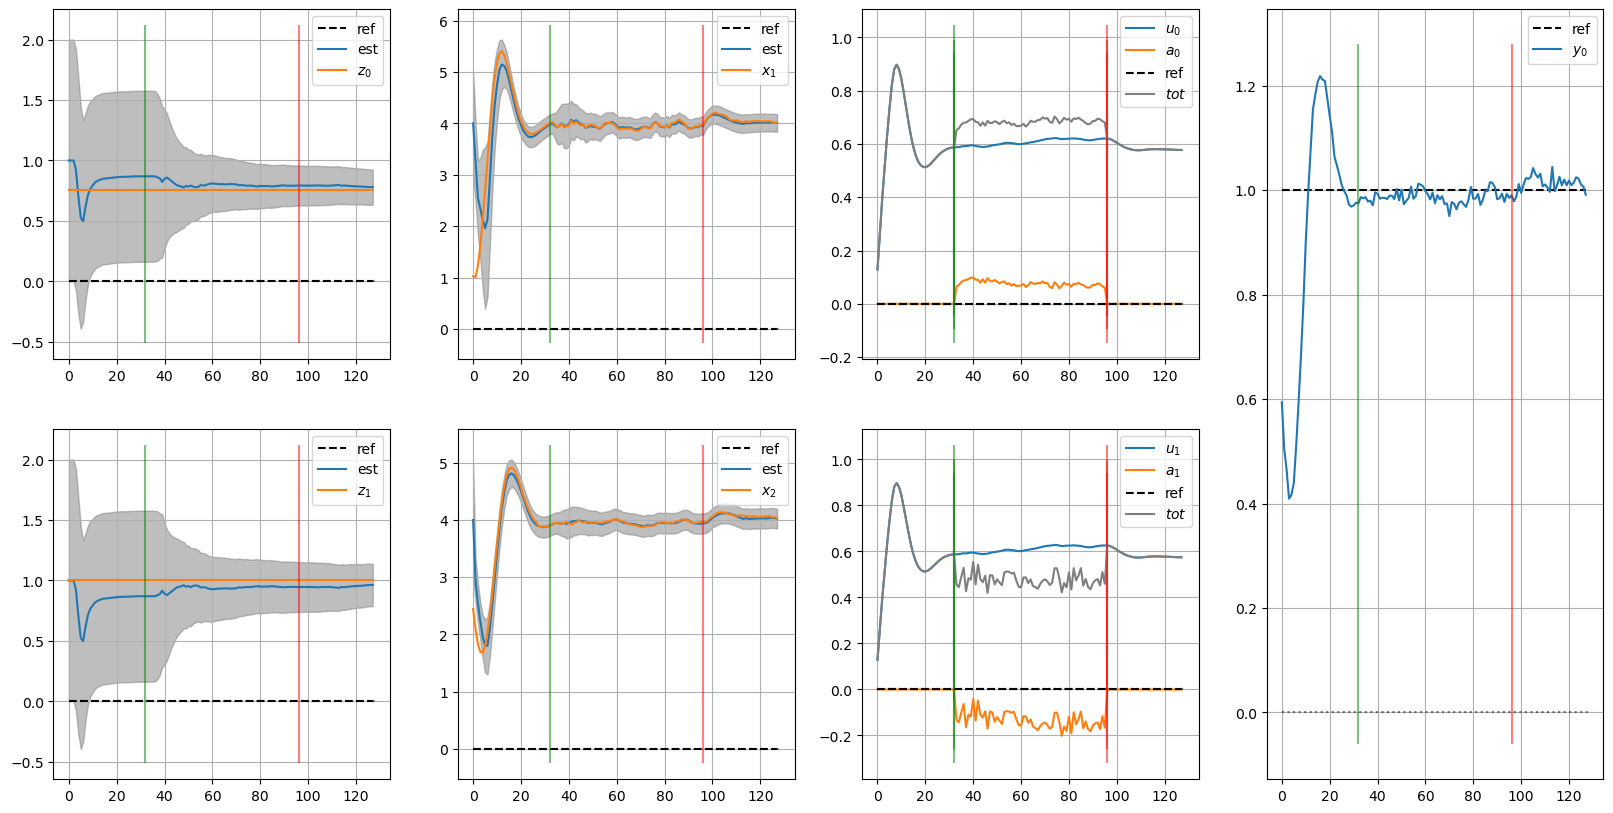

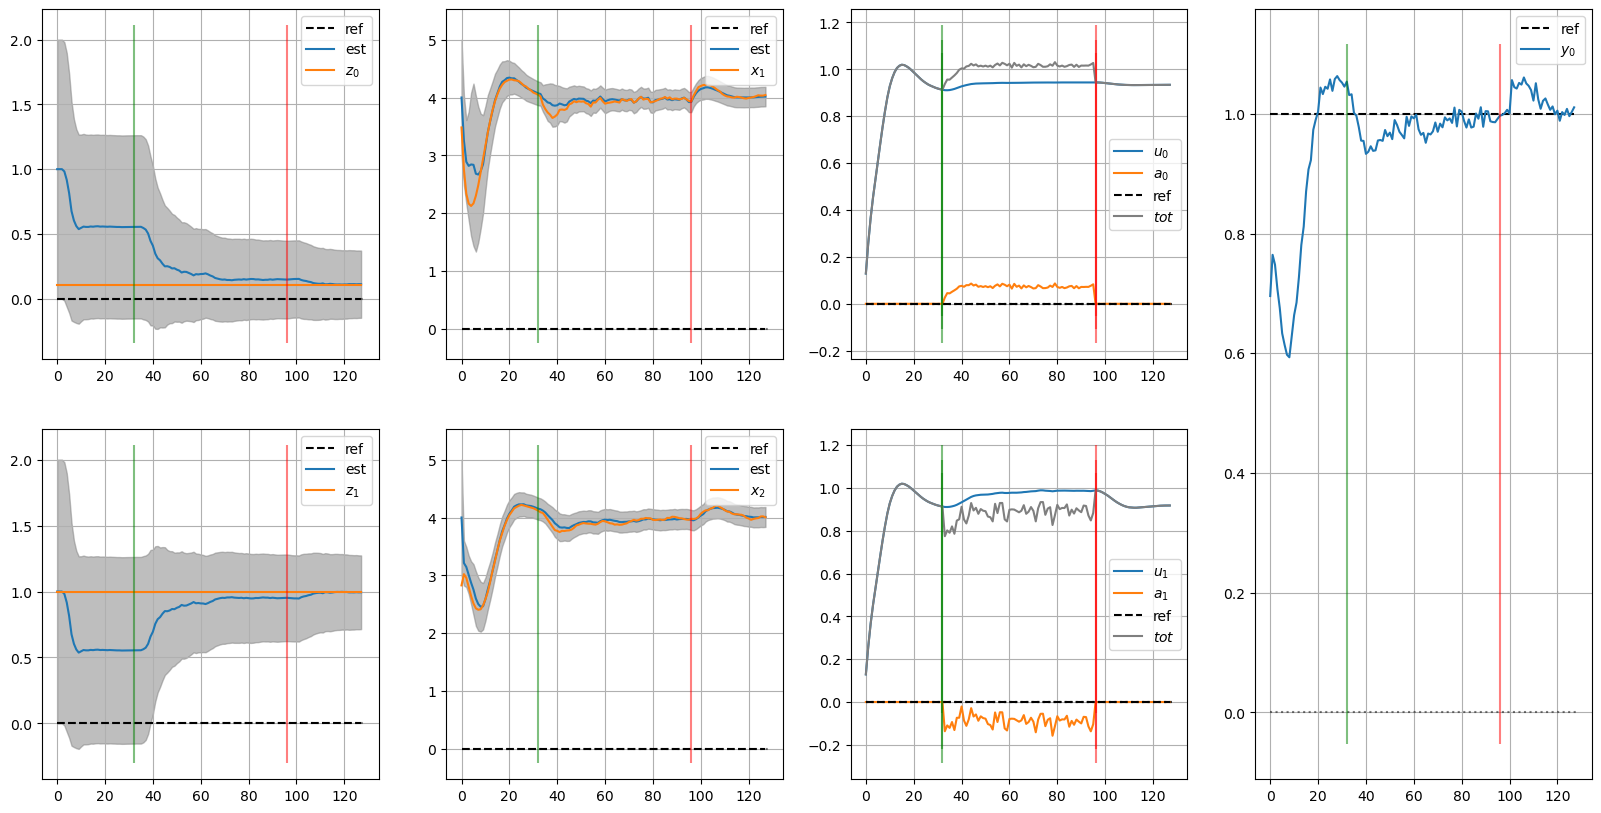

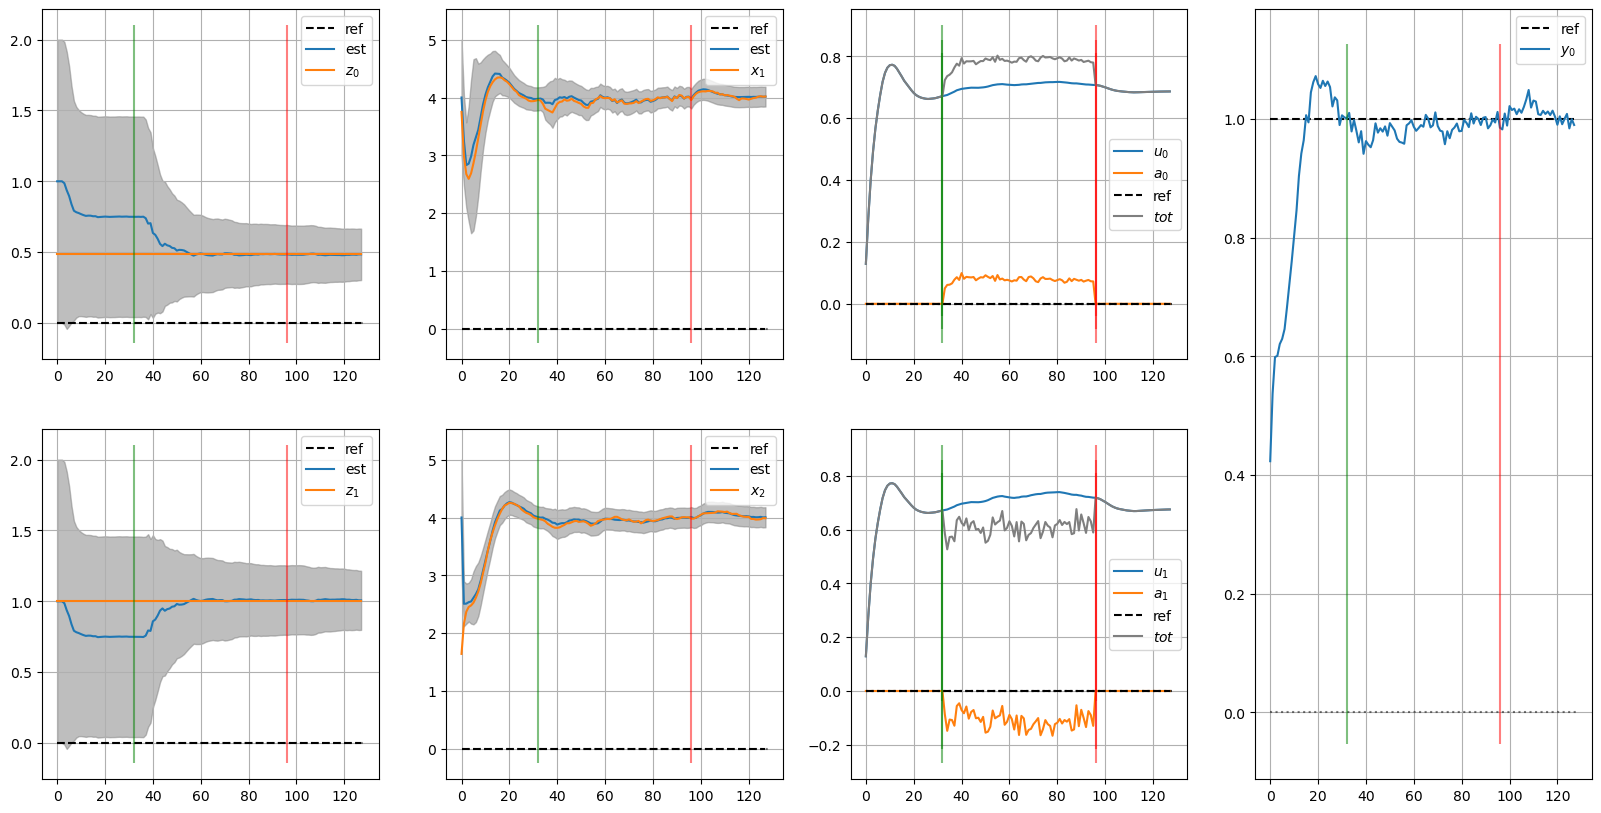

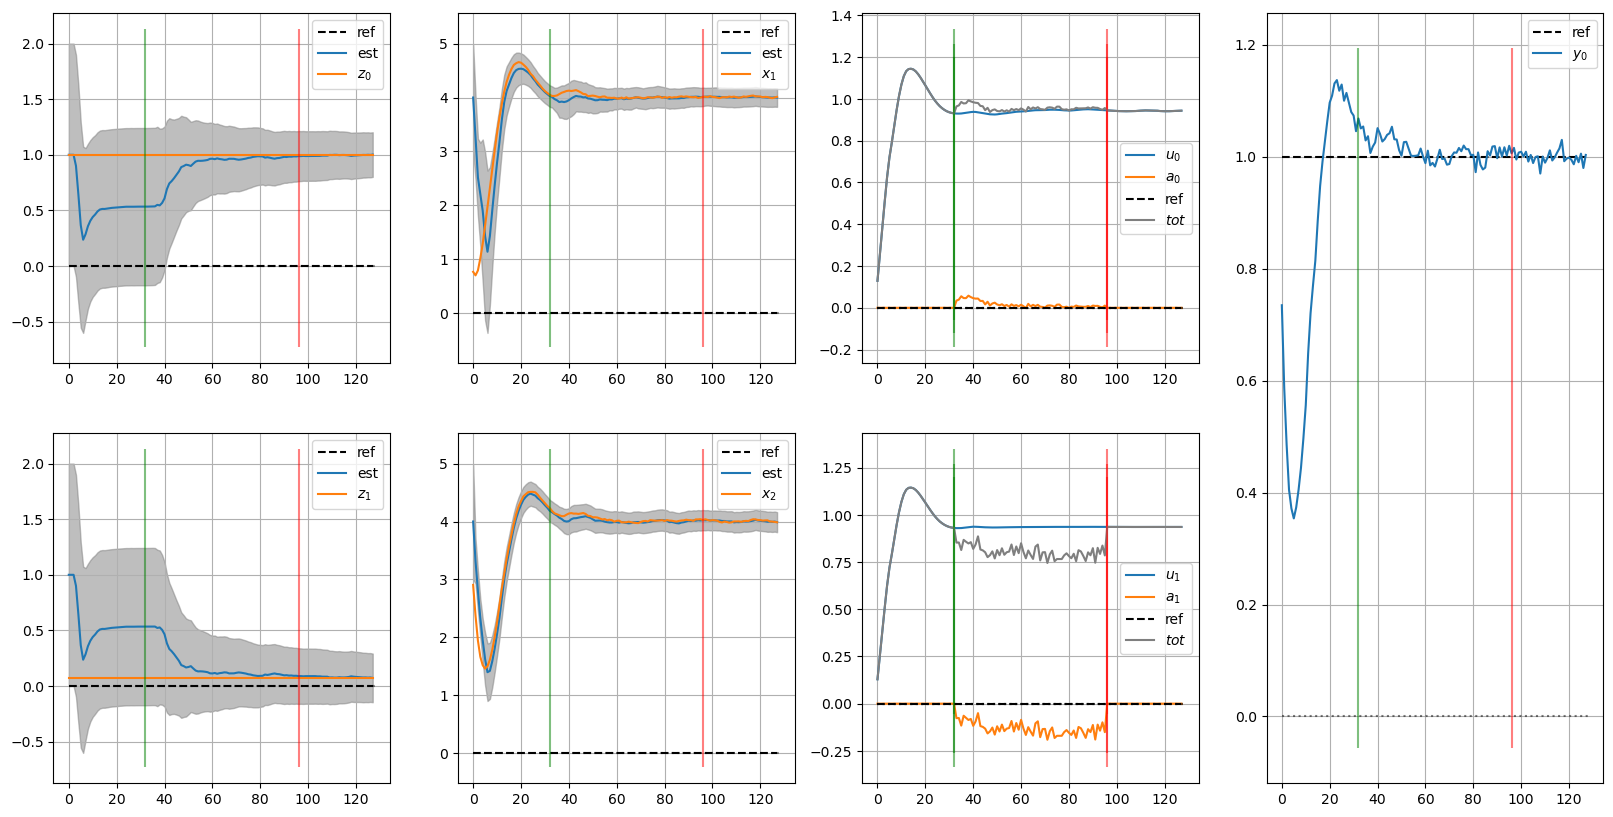

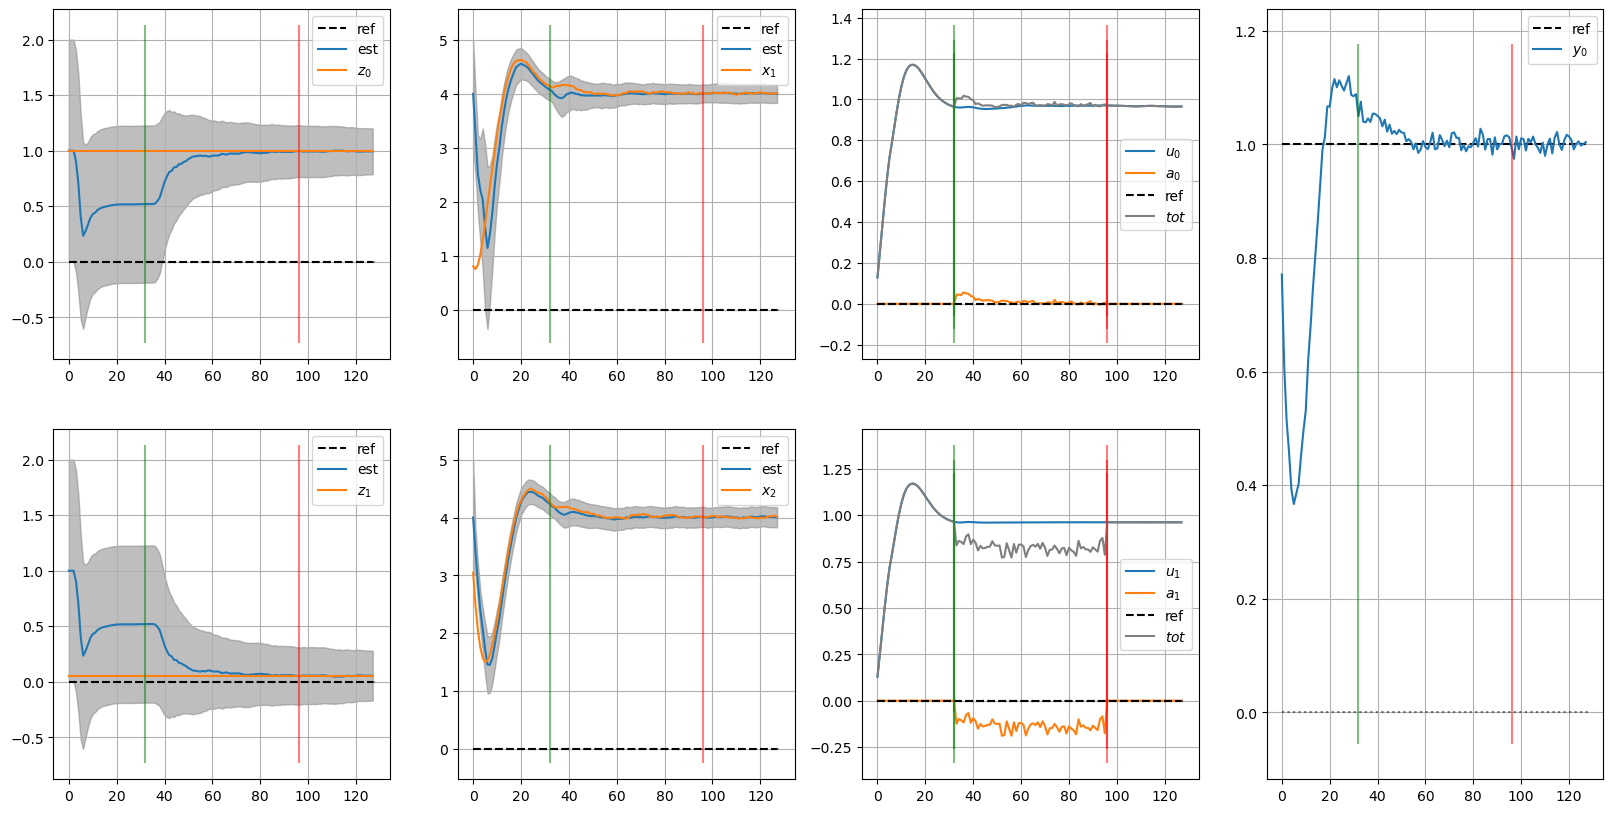

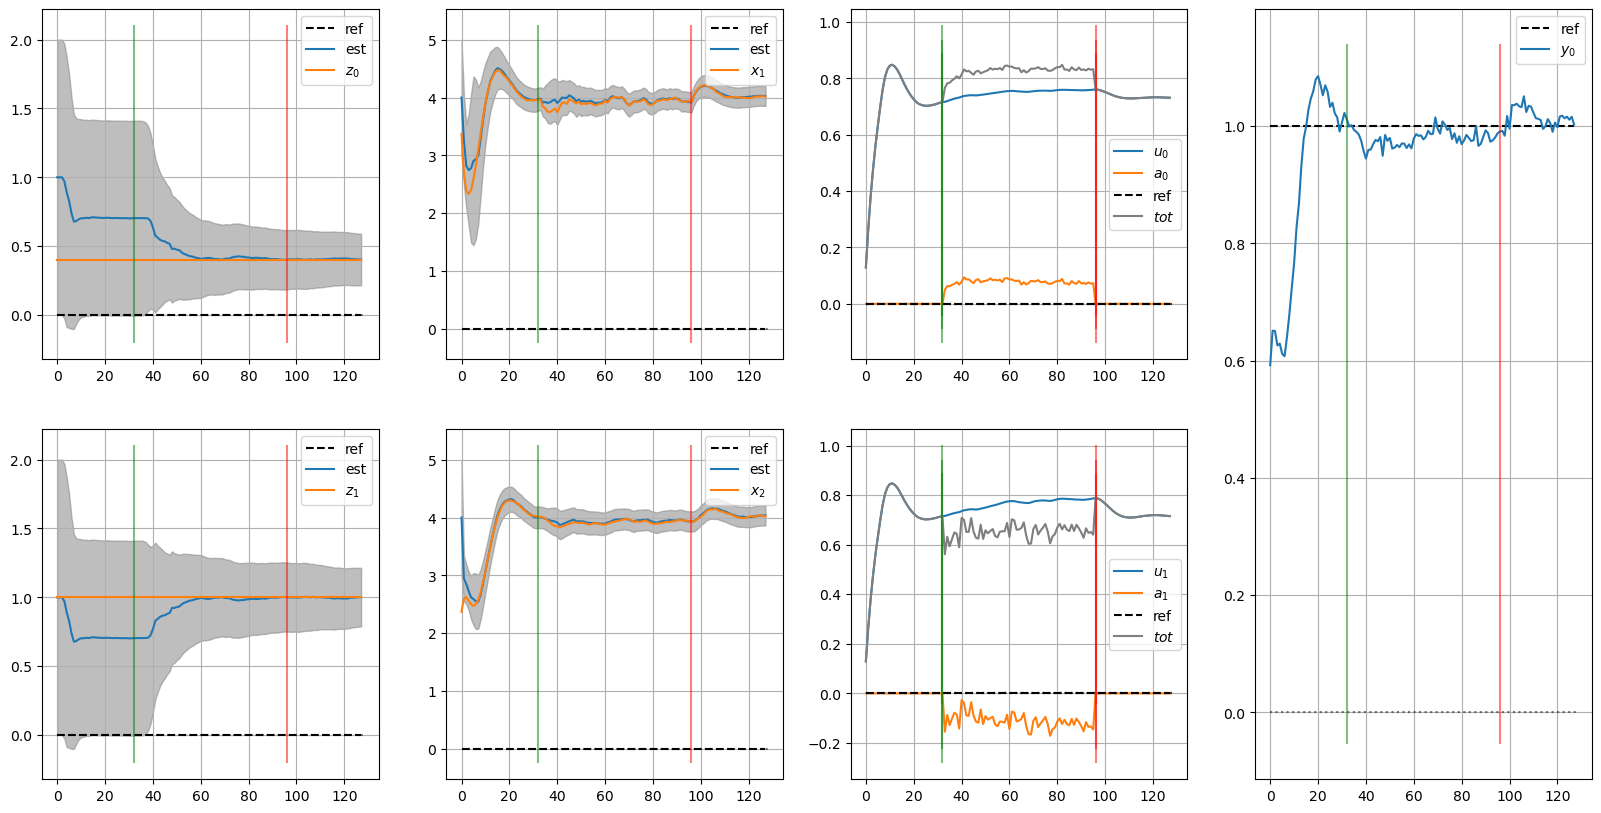

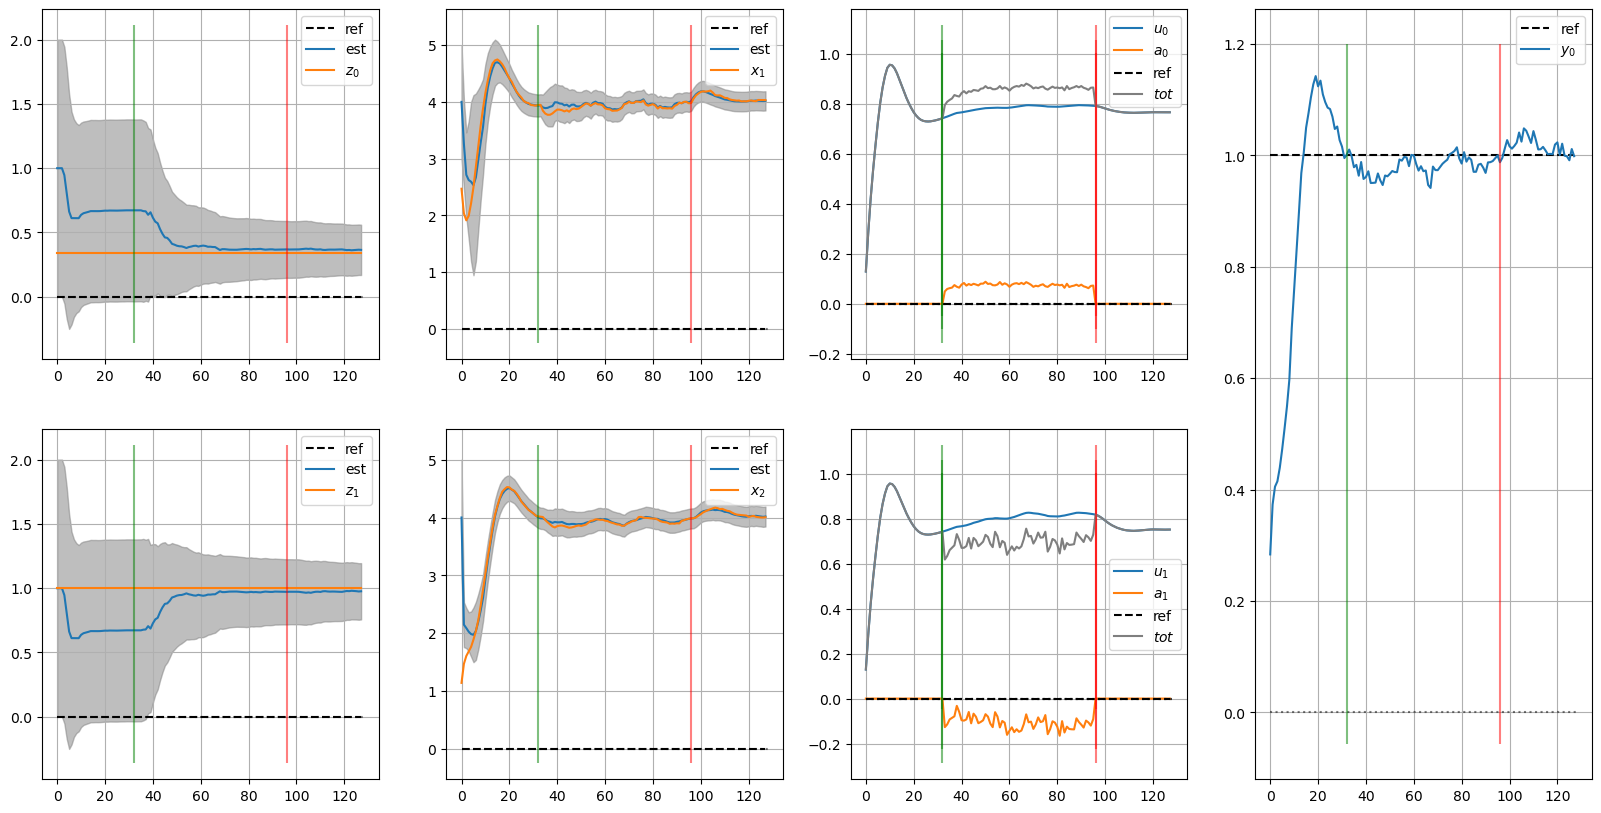

In [7]:
policy = trainer.policy

costs, rewards = [], []
for i in range(100):
    rollout, out = trainer.env.rollout(policy)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    costs.append(C)
    rewards.append(R)
costs, rewards = jnp.array(costs), jnp.array(rewards)
print(f"Mean return: {jnp.mean(rewards)} +- {jnp.std(rewards)}")
print(f"Mean cost: {jnp.mean(costs)} +- {jnp.std(costs)}")

for i in range(10):
    rollout, out = trainer.env.rollout(policy)    
    trainer.env.render(out)